In [1]:
from Other_classes import (FoodDataset, PatchEmbedding, Encoder_block, 
TransformerEncoder, insert_mask_tokens, MAE_Decoder_Block, MAEDecoder, patchify, MultiParquetFoodDataset)

In [2]:
from positional_encoding import Positional_Encoding
from torchvision import transforms
import torch
from torch import nn
from PIL import Image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
def random_masking(x, mask_ratio=0.75):
    
    """
    x: [B, N, D]
    """
    
    B, N, D = x.shape
    
    len_keep = int(N * (1 - mask_ratio))
    
    # ---- random noise generate ----
    noise = torch.rand(B, N, device=x.device)
    
    # ---- shuffle indices ----
    ids_shuffle = torch.argsort(noise, dim=1)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    
    # ---- keep first tokens ----
    ids_keep = ids_shuffle[:, :len_keep]
    
    x_masked = torch.gather(
        x,
        dim=1,
        index=ids_keep.unsqueeze(-1).repeat(1, 1, D)
    )
    
    # ---- create mask ----
    mask = torch.ones(B, N, device=x.device)
    mask[:, :len_keep] = 0
    
    # unshuffle mask
    mask = torch.gather(mask, dim=1, index=ids_restore)
    
    return x_masked, mask, ids_restore

In [5]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
img = Image.open("test_image.jpg").convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)  # [1,3,224,224]

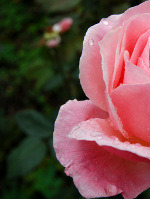

In [7]:
img

In [8]:
patch_embed = PatchEmbedding().to(device)
# batch = next(iter(dataloader))
# print("batch_shape: ", batch.shape)

tokens = patch_embed(img_tensor)
print("tokens_shape:" , tokens.shape)


visible_tokens, mask, ids_restore = random_masking(tokens)


d_model = 768  # main model dimension
num_heads = 8  # number of heads
d_ff = 2048    # feedforward hidden dimension
seq_len = 196  # max input length
vocab_size = 30000

pos_encoding = Positional_Encoding(seq_len, d_model).to(device)
visible_tokens = pos_encoding(visible_tokens)

encoder = TransformerEncoder(num_layers=8, d_model=768, d_ff=2048, num_heads=8).to(device)

latent = encoder(visible_tokens)
print("latent.shape: ", latent.shape)

mask_token = nn.Parameter(torch.zeros(1, 1, 768)).to(device)

decoder = insert_mask_tokens(latent, ids_restore, mask_token)
print("decoder_input_shape: ", decoder.shape)

tokens_shape: torch.Size([1, 196, 768])
latent.shape:  torch.Size([1, 49, 768])
decoder_input_shape:  torch.Size([1, 196, 768])


In [9]:
class MAE_inference(nn.Module):

    def __init__(self, seq_len=196, embed_dim=768):
        super().__init__()

        self.patch_embed = PatchEmbedding()
        self.encoder = TransformerEncoder(
            num_layers=8,
            d_model=768,
            d_ff=2048,
            num_heads=8
        )

        self.decoder = MAEDecoder(   # ✅ MODULE
            depth=4,
            embed_dim=768,
            d_ff=2048,
            num_heads=8,
            patch_dim=768
        )

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_encoding = Positional_Encoding(seq_len, embed_dim)

    def forward(self, images):

        tokens = self.patch_embed(images)
        visible_tokens, mask, ids_restore = random_masking(tokens)

        visible_tokens = self.pos_encoding(visible_tokens)
        latent = self.encoder(visible_tokens)

        decoder_input = insert_mask_tokens(
            latent, ids_restore, self.mask_token
        )

        pred = self.decoder(decoder_input)
        target = patchify(images)

        target = (target - target.mean(dim=-1, keepdim=True)) / \
                 (target.std(dim=-1, keepdim=True) + 1e-6)

        return pred, target, mask

In [10]:
checkpoint = torch.load("checkpoints/mae_epoch_new_69.pth", map_location=device)

model = MAE_inference().to(device)
model.load_state_dict(checkpoint["model"])  # 🔥 MAIN FIX
model.eval()

MAE_inference(
  (patch_embed): PatchEmbedding(
    (proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x Encoder_block(
        (ffn): feedforward(
          (fc1): Linear(in_features=768, out_features=2048, bias=True)
          (relu): ReLU()
          (fc2): Linear(in_features=2048, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (multi_att): MultiHeadAttention(
          (Q): Linear(in_features=768, out_features=768, bias=True)
          (K): Linear(in_features=768, out_features=768, bias=True)
          (V): Linear(in_features=768, out_features=768, bias=True)
          (fc_out): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm_layer1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm_layer2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
     

In [11]:
with torch.no_grad():
    pred, target, mask = model(img_tensor)

In [12]:
pred.shape, target.shape, mask.shape 

(torch.Size([1, 196, 768]), torch.Size([1, 196, 768]), torch.Size([1, 196]))

In [13]:
loss = (pred - target) ** 2
loss = loss.mean(dim=-1)          # (1, 196)
masked_loss = (loss * mask).sum() / mask.sum()

print("Masked reconstruction loss:", masked_loss.item())

Masked reconstruction loss: 1.684921145439148


In [14]:
def unpatchify(patches, patch_size=16, img_size=224):
    """
    patches: [B, N, C*ps*ps]
    return:  [B, C, H, W]
    """
    B, N, D = patches.shape
    C = 3
    h = w = img_size // patch_size  # 14

    patches = patches.view(B, N, C, patch_size, patch_size)
    # [B, N, C, ps, ps]

    patches = patches.view(B, h, w, C, patch_size, patch_size)
    # [B, 14, 14, C, ps, ps]

    patches = patches.permute(0, 3, 1, 4, 2, 5)
    # [B, C, 14, ps, 14, ps]

    images = patches.reshape(B, C, img_size, img_size)
    return images

In [15]:
recon_img = unpatchify(pred)
orig_img  = img_tensor

In [16]:
mask_img = mask.reshape(1, 14, 14)
mask_img = mask_img.repeat_interleave(16, 1).repeat_interleave(16, 2)
mask_img = mask_img.unsqueeze(1)   # (1,1,224,224)

In [17]:
final_img = orig_img * (1 - mask_img) + recon_img * mask_img

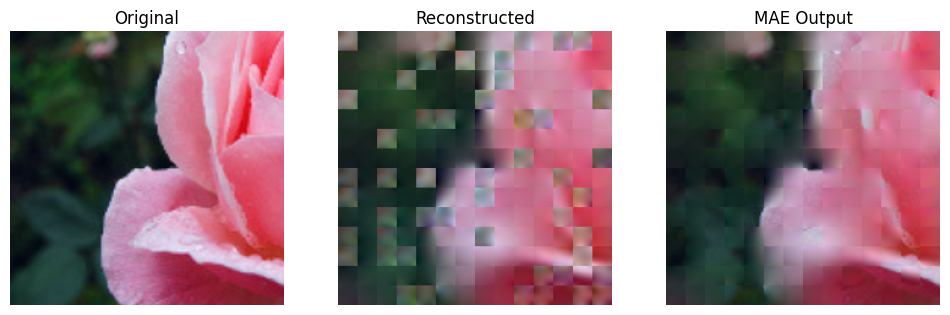

In [18]:
import matplotlib.pyplot  as plt
def show(img, title):
    img = img[0].cpu().permute(1,2,0)
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); show(orig_img, "Original")
plt.subplot(1,3,2); show(recon_img, "Reconstructed")
plt.subplot(1,3,3); show(final_img, "MAE Output")
plt.show()

In [19]:
import pyarrow.parquet as pq

pq_file = "data/train-00000-of-00008-26f523e9bdcc2b9a.parquet"

table = pq.read_table(pq_file)
print(table.schema)

image: struct<bytes: binary, path: string>
  child 0, bytes: binary
  child 1, path: string
label: int64
id: int64
clip_tags_ViT_L_14_with_openai_classes: list<item: string>
  child 0, item: string
clip_tags_ViT_L_14_wo_openai_classes: list<item: string>
  child 0, item: string
clip_tags_ViT_L_14_simple_specific: string
clip_tags_ViT_L_14_ensemble_specific: string
clip_tags_ViT_B_16_simple_specific: string
clip_tags_ViT_B_16_ensemble_specific: string
clip_tags_ViT_B_32_simple_specific: string
clip_tags_ViT_B_32_ensemble_specific: string
Attributes_ViT_L_14_descriptors_text_davinci_003_full: list<item: string>
  child 0, item: string
Attributes_LAION_ViT_H_14_2B_descriptors_text_davinci_003_full: list<item: string>
  child 0, item: string
clip_tags_LAION_ViT_H_14_2B_simple_specific: string
clip_tags_LAION_ViT_H_14_2B_ensemble_specific: string
-- schema metadata --
huggingface: '{"info": {"features": {"image": {"_type": "Image"}, "label"' + 2709


In [20]:
print(table.column_names)

['image', 'label', 'id', 'clip_tags_ViT_L_14_with_openai_classes', 'clip_tags_ViT_L_14_wo_openai_classes', 'clip_tags_ViT_L_14_simple_specific', 'clip_tags_ViT_L_14_ensemble_specific', 'clip_tags_ViT_B_16_simple_specific', 'clip_tags_ViT_B_16_ensemble_specific', 'clip_tags_ViT_B_32_simple_specific', 'clip_tags_ViT_B_32_ensemble_specific', 'Attributes_ViT_L_14_descriptors_text_davinci_003_full', 'Attributes_LAION_ViT_H_14_2B_descriptors_text_davinci_003_full', 'clip_tags_LAION_ViT_H_14_2B_simple_specific', 'clip_tags_LAION_ViT_H_14_2B_ensemble_specific']


In [21]:
df = table.select(["label"]).to_pandas()

print("Unique labels:", df["label"].nunique())
print(df["label"].value_counts().head(10))

Unique labels: 13
label
6     750
79    750
81    750
53    750
10    750
20    750
77    750
48    750
86    750
84    750
Name: count, dtype: int64


In [22]:
import json

meta = table.schema.metadata
hf_info = json.loads(meta[b"huggingface"].decode())
label_names = hf_info["info"]["features"]["label"]["names"]

print(label_names[:10])

['apple pie', 'baby back ribs', 'baklava', 'beef carpaccio', 'beef tartare', 'beet salad', 'beignets', 'bibimbap', 'bread pudding', 'breakfast burrito']


In [28]:
label_names = hf_info["info"]["features"]["clip_tags_ViT_B_16_simple_specific"]

print(label_names)

{'dtype': 'string', '_type': 'Value'}


In [34]:
# print(table.select[0]["clip_tags_ViT_B_16_simple_specific"])
df1 = table.select(["Attributes_ViT_L_14_descriptors_text_davinci_003_full"]).to_pandas()

In [35]:
df1

,Attributes_ViT_L_14_descriptors_text_davinci_003_full
0,"[beignet which has square or round in shape, b..."
1,"[beignets which has served warm, beignets whic..."
2,"[beignets which has round or square shape, bei..."
3,[fritter which may be served with a dipping sa...
4,"[beignet which has square or round in shape, b..."
...,...
9464,"[nacho which has guacamole, nachos which is a ..."
9465,"[guacamole which has jalapeno peppers, ceviche..."
9466,"[guacamole which has green, mashed avocado, gu..."
9467,"[guacamole which is a bowl or plate, guacamole..."


In [44]:
df1.shape

(9469, 1)

In [45]:
df1.iloc[1,:]

Attributes_ViT_L_14_descriptors_text_davinci_003_full    [beignets which has served warm, beignets whic...
Name: 1, dtype: object

In [46]:
print(df1["Attributes_ViT_L_14_descriptors_text_davinci_003_full"].iloc[0])

['beignet which has square or round in shape'
 'beignets which has round or square shape'
 'beignets which has served warm'
 'pancake which has fork, knife, or other utensils'
 'beignets which has deep-fried dough']


In [47]:
print(df1["Attributes_ViT_L_14_descriptors_text_davinci_003_full"].iloc[1])

['beignets which has served warm'
 'beignets which has round or square shape'
 'beignets which has pillowy texture'
 'beignets which has deep-fried dough' 'beignets which has sugar coating']


In [49]:
print(df1["Attributes_ViT_L_14_descriptors_text_davinci_003_full"].iloc[9468])

['guacamole which is a bowl or plate'
 'guacamole which has green, mashed avocado'
 'guacamole which has jalapeno peppers'
 'nachos which is a side of guacamole or salsa'
 'nacho which has guacamole']


In [50]:
df.shape

(9469, 1)

In [60]:
pq_file = "data/train-00007-of-00008-509676e94aeabcee.parquet"

table1 = pq.read_table(pq_file)

In [61]:
df2 = table1.select(["Attributes_ViT_L_14_descriptors_text_davinci_003_full"]).to_pandas()

In [62]:
df2.shape

(9468, 1)

In [63]:
print(df2["Attributes_ViT_L_14_descriptors_text_davinci_003_full"].iloc[9467])

['spaghetti bolognese which has plate of spaghetti'
 'spaghetti bolognese which has tomatoes'
 'spaghetti bolognese which has herbs'
 'spaghetti bolognese which is a spoon or fork'
 'spaghetti bolognese which has onions']
